# Assignment 2 
## DATA 620
### Jane Song

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import nltk
import gzip

## Import data and select data
This dataset is the Amazon fine foods reviews with data spanning over 10 years and ~500,000 reviews.  

In [2]:
with gzip.open("finefoods.txt.gz", "rt", encoding="utf-8") as f:
    for i in range(20):
        print(f.readline().strip())

product/productId: B001E4KFG0
review/userId: A3SGXH7AUHU8GW
review/profileName: delmartian
review/helpfulness: 1/1
review/score: 5.0
review/time: 1303862400
review/summary: Good Quality Dog Food
review/text: I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

product/productId: B00813GRG4
review/userId: A1D87F6ZCVE5NK
review/profileName: dll pa
review/helpfulness: 0/0
review/score: 1.0
review/time: 1346976000
review/summary: Not as Advertised
review/text: Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

product/productId: B000LQOCH0
review/userId: ABXLMWJIXXAIN


From the selected dataset, the reviews by product and userID will be evaluated for this assignment. 

In [ ]:
reviews = []
with gzip.open("finefoods.txt.gz", "rt", encoding="latin-1") as f:
    review = {}

    for line in f:
        line = line.strip()

        if line.startswith("product/productId:"):
            review["product"] = line.split(":", 1)[1].strip()

        elif line.startswith("review/userId:"):
            review["user"] = line.split(":", 1)[1].strip()

        elif line  == "":
            if "product" in review and "user" in review:
                reviews.append(review)
            review = {}

print("Number of reviews:", len(reviews))
print(reviews[:3] )

Number of reviews: 568454
[{'product': 'B001E4KFG0', 'user': 'A3SGXH7AUHU8GW'}, {'product': 'B00813GRG4', 'user': 'A1D87F6ZCVE5NK'}, {'product': 'B000LQOCH0', 'user': 'ABXLMWJIXXAIN'}]


Due to the very high number of reviews, 5000 will be selected for this assignment. 

In [6]:
reviews_sample = reviews[:5000]

print("Number of reviews:", len(reviews_sample))

Number of reviews: 5000


## Build the network
From these 5000 reviews, the number of nodes, edges, and connections will be evaluated 

In [21]:
amazon = nx.Graph()

for review in reviews_sample:
    user = "user_" + review["user"]
    product = "product_" + review["product"]
    
    amazon.add_node(user, type="user")
    amazon.add_node(product, type="product")
    amazon.add_edge(user, product)

print("Number of nodes:", amazon.number_of_nodes())
print("Number of edges:", amazon.number_of_edges())

Number of nodes: 5535
Number of edges: 4940


In [23]:
print("Number of connected components:", nx.number_connected_components(amazon))

largest_component = max(nx.connected_components(amazon), key=len)

amazon_connected = amazon.subgraph(largest_component).copy()

print("Nodes in largest component:", amazon_connected.number_of_nodes())
print("Edges in largest component:", amazon_connected.number_of_edges())

diameter = nx.diameter(amazon_connected)

print("Graph diameter:", diameter)

Number of connected components: 608
Nodes in largest component: 2245
Edges in largest component: 2253
Graph diameter: 14


## Visualization
Due to the number of nodes in this dataset, only the network's top 100 nodes with the highest degree will be visualized.

In [ ]:
# Select the top 100 nodes with the highest degrees
top_nodes = sorted(
    amazon_connected.degree(),
    key=lambda x: x[1],
    reverse=True)[:100]

top_nodes = [node for node, degree in top_nodes]

amazon_plot = amazon_connected.subgraph(top_nodes).copy()

# Split users and products
user_nodes = [
    node for node, data in amazon_plot.nodes(data=True)
    if data["type"] == "user"]

product_nodes = [
    node for node, data in amazon_plot.nodes(data=True)
    if data["type"]== "product" ]



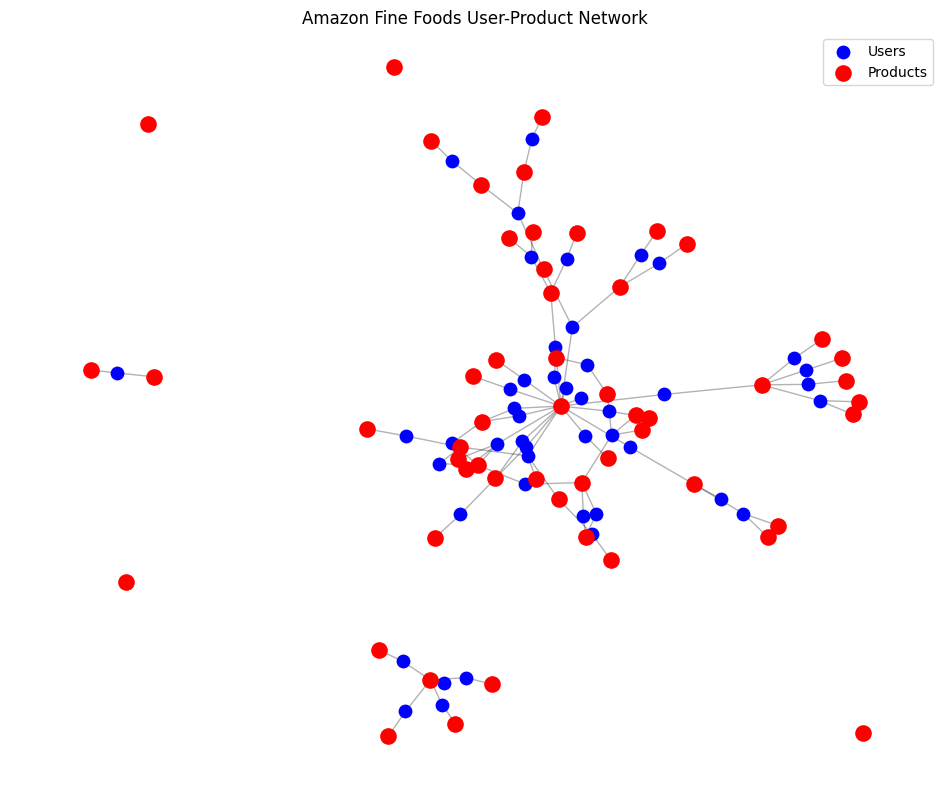

In [ ]:
# Create layout
amazon_network = nx.spring_layout(amazon_plot, seed=123)

plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(
    amazon_plot,
    amazon_network,
    nodelist = user_nodes,
    node_size = 80,
    node_color= "blue",
    label= "Users")

nx.draw_networkx_nodes(
    amazon_plot,
    amazon_network,
    nodelist= product_nodes,
    node_size= 120,
    node_color="red",
    label="Products")

nx.draw_networkx_edges(
    amazon_plot,
    amazon_network,
    alpha=0.3)

plt.title("Amazon Fine Foods User-Product Network")
plt.legend()
plt.axis("off")
plt.show()

## Conclusion 
From this visualization, we can see a center cluster that suggests that some users and products are more connected than others. The highly connected nodes in this section may suggest products reviewed by many users. We can also see a few smaller clusters that are not connected to the central cluster. There are also completely isolated nodes of products. These likely have minimal connection in the original network but due to limiting the number of nodes in this visualization, they are isolated. 